<a href="https://colab.research.google.com/github/siva567-pixel/supervisedlearningcasestudy/blob/main/Supervised_Learning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris.value_counts()

sepal_length  sepal_width  petal_length  petal_width  species  
5.8           2.7          5.1           1.9          virginica    2
4.4           2.9          1.4           0.2          setosa       1
              3.0          1.3           0.2          setosa       1
              3.2          1.3           0.2          setosa       1
4.3           3.0          1.1           0.1          setosa       1
                                                                  ..
7.7           2.6          6.9           2.3          virginica    1
              2.8          6.7           2.0          virginica    1
              3.0          6.1           2.3          virginica    1
              3.8          6.7           2.2          virginica    1
7.9           3.8          6.4           2.0          virginica    1
Name: count, Length: 149, dtype: int64

In [ ]:
iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


<Axes: xlabel='sepal_length', ylabel='Count'>

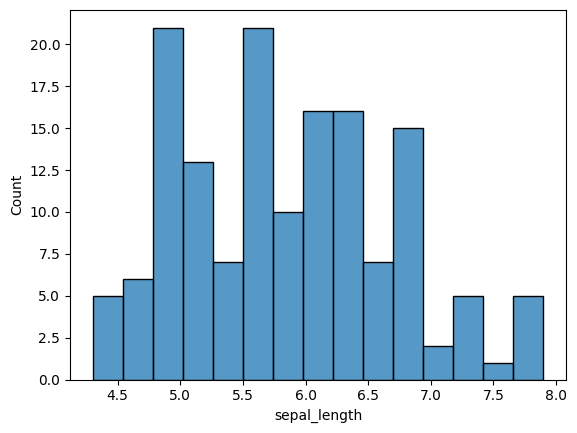

In [ ]:
sns.histplot(data=iris,x='sepal_length',bins=15)

<Axes: xlabel='sepal_width', ylabel='Count'>

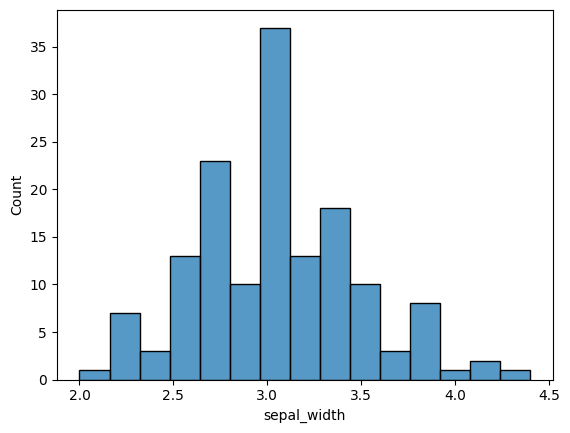

In [ ]:
sns.histplot(data=iris,x='sepal_width',bins=15)

<Axes: xlabel='petal_length', ylabel='Count'>

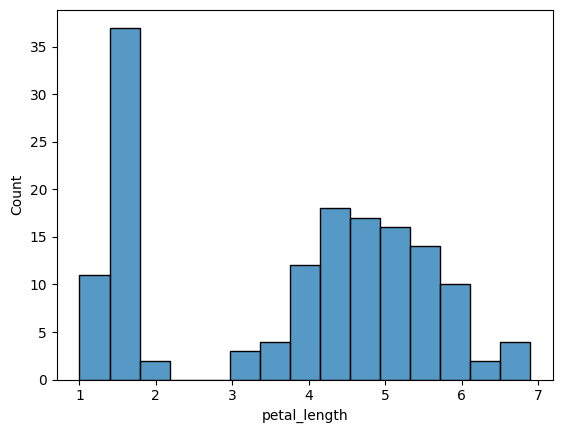

In [ ]:
sns.histplot(data=iris,x='petal_length',bins=15)

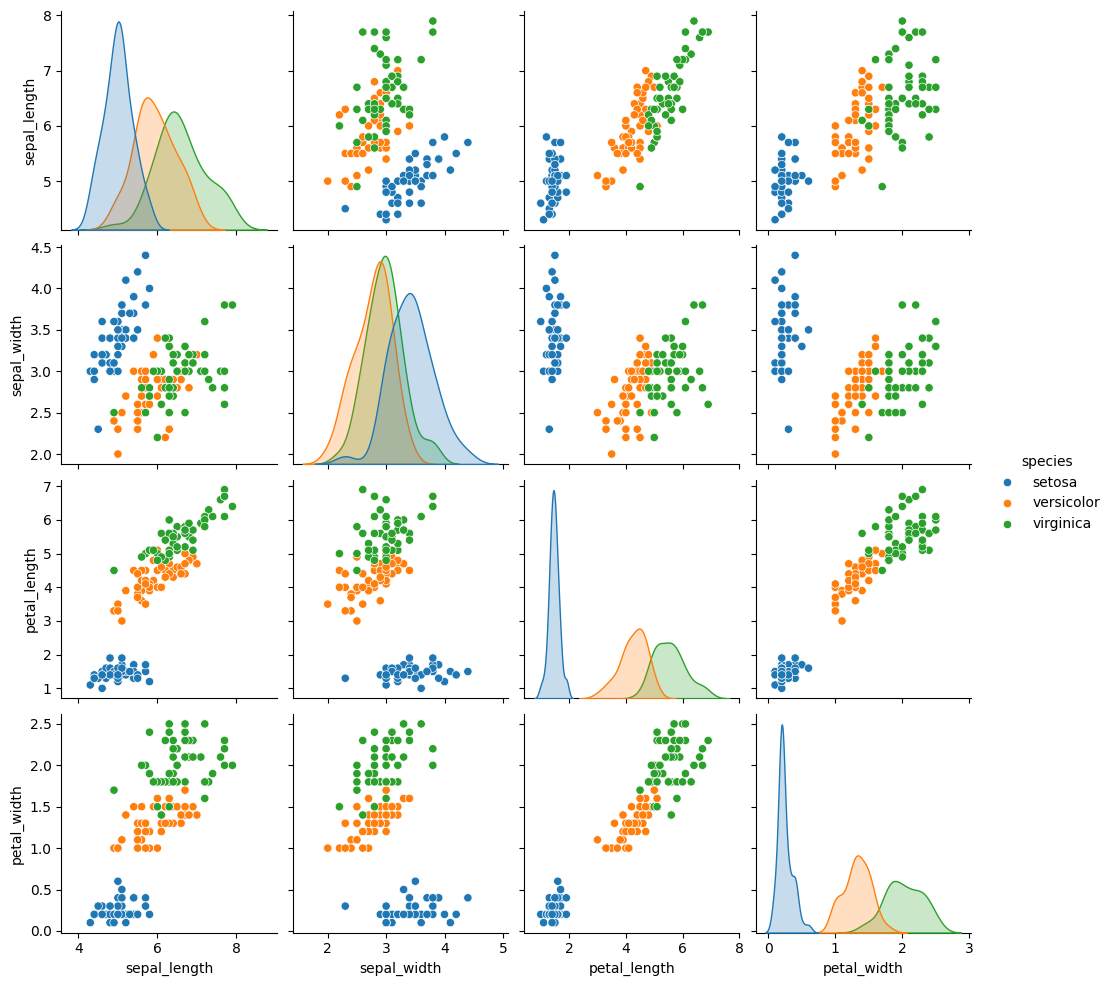

In [ ]:
sns.pairplot(iris,hue='species')

In [ ]:
iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
y = iris['species']
x = iris.drop(columns = ['species'])

le = LabelEncoder()
y = le.fit_transform(y)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

pd.Series(y_train).value_counts()

(120, 4) (30, 4) (120,) (30,)


,count
0,40
2,40
1,40


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred = log_model.predict(x_test_scaled)

In [ ]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
0.9333333333333333


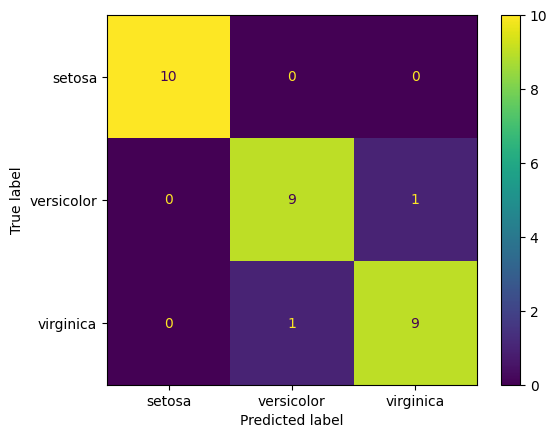

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)
plt.show()

In [ ]:
#KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

metric_k=[]
neighbours = np.arange(3,20)

for i in neighbours:
    knn_model = KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(x_train_scaled,y_train)
    y_pred_knn = knn_model.predict(x_test_scaled)
    metric_k.append(accuracy_score(y_test,y_pred_knn))

    metric_k

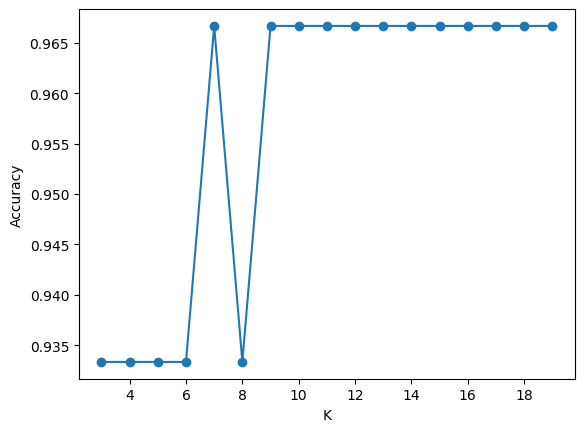

In [ ]:
plt.plot(neighbours,metric_k,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=11)
knn_classifier.fit(x_train_scaled,y_train)
y_pred_knn = knn_classifier.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.9666666666666667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


**Naive Bayes Classifier**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred_nb = nb_model.predict(x_test_scaled)

print(accuracy_score(y_test,y_pred_nb))
print(confusion_matrix(y_test,y_pred_nb))

0.9666666666666667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier()
dec_tree.fit(x_train_scaled,y_train)
y_pred_dt = dec_tree.predict(x_test_scaled)

print(accuracy_score(y_test,y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))


0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


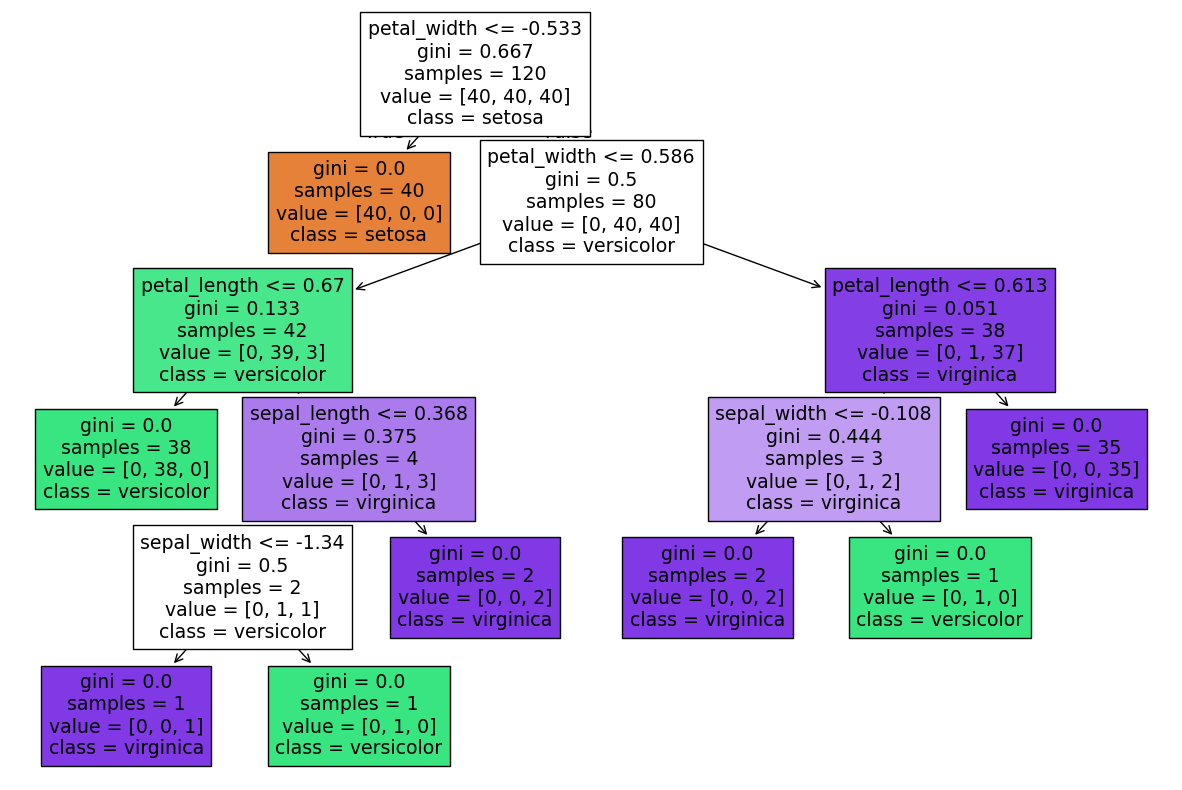

In [ ]:
from sklearn.tree import plot_tree

feature_names = x_train.columns.tolist()
class_names = le.classes_.tolist()

plt.figure(figsize=(15,10))
plot_tree(dec_tree,feature_names=feature_names,class_names=class_names,filled=True)
plt.show()

In [ ]:
dec_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
dec_tree = DecisionTreeClassifier(random_state = 12, min_samples_split=5, min_samples_leaf=5,max_depth = 2)
dec_tree.fit(x_train_scaled,y_train)
y_pred_dt = dec_tree.predict(x_test_scaled)

print(accuracy_score(y_test,y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))

0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [ ]:
dec_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 2,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 12,
 'splitter': 'best'}

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(x_train_scaled,y_train)
y_pred_rf = rf_model.predict(x_test_scaled)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.9333333333333333
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [ ]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rf_model = RandomForestClassifier(random_state = 42, n_estimators = 200, n_jobs=-1, class_weight= 'balanced', max_depth = 10, min_samples_split =5)

rf_model.fit(x_train_scaled,y_train)
y_pred_rf = rf_model.predict(x_test_scaled)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.9666666666666667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
